In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from matplotlib import cm # 用于颜色映射
import string
# ==========================================
# 1. 数据准备 (已修正部分标签错误)
# ==========================================
models = ["G-BERT", "BEHRT", "Med-BERT", "HypEHR", "ExBEHRT", "HEART", "DT-BEHRT"]

# Overall Performance
overall_auprc = pd.DataFrame(
    {
        "Mortality":   [72.13, 75.33, 75.28, 76.39, 81.44, 82.76, 84.50],
        "PLOS":        [72.48, 72.49, 76.98, 88.70, 83.52, 83.03, 85.00],
        "Readmission": [57.19, 51.59, 62.90, 56.00, 63.91, 67.41, 66.44],
    },
    index=models,
)

# Subgroup Performance
# 注意：我已将原数据中标记为 "PLOS ... (readm block top)" 的行
# 修正为 "Readmission" 任务，并去掉了后缀，以保证计算基准正确。
rows = [
    # ========== Mortality ==========
    ("Mortality", "Diabetes",      [np.nan, 73.07, np.nan, 76.96, 80.19, 81.05, 81.43]),
    ("Mortality", "Hypertension",  [np.nan, 73.57, np.nan, 76.43, 80.03, 81.00, 83.22]),
    ("Mortality", "Chronic kidney disease",
                                   [np.nan, 73.84, np.nan, 72.39, 80.45, 81.52, 74.26]),
    ("Mortality", "Heart failure", [np.nan, 74.13, np.nan, 70.45, 80.31, 81.06, 77.67]),
    ("Mortality", "Coronary artery disease",
                                   [np.nan, 72.40, np.nan, 75.04, 80.28, 80.78, 84.14]),
    ("Mortality", "COPD",          [np.nan, 72.41, np.nan, 69.51, 79.96, 80.16, 76.86]), # 缩写方便显示
    ("Mortality", "Liver disease", [np.nan, 73.95, np.nan, 85.24, 78.47, 81.53, 89.13]),
    ("Mortality", "Cancer",        [np.nan, 74.05, np.nan, 78.95, 80.07, 80.65, 84.07]),

    # ========== PLOS ==========
    ("PLOS", "Diabetes",           [np.nan, 72.04, np.nan, 80.65, 83.79, 84.49, 84.91]),
    ("PLOS", "Hypertension",       [np.nan, 71.35, np.nan, 79.03, 84.10, 84.28, 83.69]),
    ("PLOS", "Chronic kidney disease",
                                   [np.nan, 71.45, np.nan, 82.80, 84.52, 84.12, 83.72]),
    ("PLOS", "Heart failure",      [np.nan, 71.61, np.nan, 82.75, 83.79, 83.88, 86.36]),
    ("PLOS", "Coronary artery disease",
                                   [np.nan, 71.96, np.nan, 77.10, 84.00, 84.60, 83.18]),
    ("PLOS", "COPD",               [np.nan, 73.04, np.nan, 79.42, 84.47, 85.30, 82.07]),
    ("PLOS", "Liver disease",      [np.nan, 71.93, np.nan, 85.41, 84.41, 83.90, 90.15]),
    ("PLOS", "Cancer",             [np.nan, 71.44, np.nan, 79.85, 84.04, 84.09, 84.71]),

    # ========== Readmission (已修正归类) ==========
    # 原数据里的 PLOS (readm block top) 其实是 Readmission 的数据
    ("Readmission", "Diabetes",    [np.nan, 53.14, np.nan, 63.71, 61.87, 64.79, 73.35]),
    ("Readmission", "Hypertension",[np.nan, 52.71, np.nan, 61.06, 63.11, 64.85, 71.59]),
    
    ("Readmission", "Chronic kidney disease",
                                   [np.nan, 51.70, np.nan, 69.27, 63.46, 63.93, 78.62]),
    ("Readmission", "Heart failure",
                                   [np.nan, 52.61, np.nan, 60.89, 63.11, 64.36, 74.79]),
    ("Readmission", "Coronary artery disease",
                                   [np.nan, 52.18, np.nan, 56.88, 65.07, 65.45, 70.84]),
    ("Readmission", "COPD",        [np.nan, 53.69, np.nan, 57.64, 61.25, 65.38, 69.35]),
    ("Readmission", "Liver disease",
                                   [np.nan, 52.67, np.nan, 57.88, 64.10, 67.16, 73.32]),
    ("Readmission", "Cancer",      [np.nan, 50.92, np.nan, 53.92, 62.71, 66.67, 68.82]),
]

index = pd.MultiIndex.from_tuples([(t, s) for t, s, _ in rows], names=["Task", "Subgroup"])
subgroup_df = pd.DataFrame([vals for _, _, vals in rows], index=index, columns=models)

# ==========================================
# 2. 执行推断 (Method 1: Relative Delta Correction)
# ==========================================

# 复制一份数据用于填补
imputed_df = subgroup_df.copy()

missing_models = ["G-BERT", "Med-BERT"]
known_models = ["BEHRT", "HypEHR", "ExBEHRT", "HEART", "DT-BEHRT"]

print("开始推断缺失值...\n")

for idx, row in imputed_df.iterrows():
    task = idx[0]      # 例如 "Mortality"
    subgroup = idx[1]  # 例如 "Diabetes"
    
    # 1. 获取已知模型在这个 Subgroup 的值
    vals_subgroup = row[known_models].astype(float)
    
    # 2. 获取已知模型在这个 Task 的 Overall 值
    vals_overall = overall_auprc.loc[known_models, task].astype(float)
    
    # 3. 计算偏差 (Delta): 该 Subgroup 相比 Overall 是更容易还是更难？
    # Delta > 0 说明该亚组比平均情况容易；Delta < 0 说明更难
    deltas = vals_subgroup.values - vals_overall.values
    avg_delta = np.nanmean(deltas)
    
    # 4. 应用偏差到缺失模型
    for model in missing_models:
        # 获取缺失模型的 Overall 分数 (基准分)
        base_score = overall_auprc.loc[model, task]
        
        # 推断分 = 基准分 + 平均偏差
        imputed_score = base_score + avg_delta
        
        # 填入表格
        imputed_df.at[idx, model] = imputed_score

# ==========================================
# 3. 结果展示
# ==========================================

# 格式化输出，保留2位小数
pd.options.display.float_format = '{:.2f}'.format

print("--- 推断完成后的数据表 (Imputed DataFrame) ---")
print(imputed_df)

# 如果你想单独看 G-BERT 和 Med-BERT 的填补结果：
print("\n--- 仅查看 G-BERT 和 Med-BERT 的推断结果 ---")
print(imputed_df[["G-BERT", "Med-BERT"]])

# 校验逻辑示例
print("\n--- 校验示例 (Mortality - Diabetes) ---")
print(f"已知模型平均偏差 (Delta): {avg_delta:.2f} (此值为最后一行循环的值，仅作演示逻辑)")
print(f"G-BERT Overall (Mortality): {overall_auprc.loc['G-BERT', 'Mortality']:.2f}")
# 注意：上面的 avg_delta 是循环最后一次的值(Readmission-Cancer)，仅为打印演示，实际计算每行都不同。

开始推断缺失值...

--- 推断完成后的数据表 (Imputed DataFrame) ---
                                     G-BERT  BEHRT  Med-BERT  HypEHR  ExBEHRT  \
Task        Subgroup                                                            
Mortality   Diabetes                  70.59  73.07     73.74   76.96    80.19   
            Hypertension              70.90  73.57     74.05   76.43    80.03   
            Chronic kidney disease    68.54  73.84     71.69   72.39    80.45   
            Heart failure             68.77  74.13     71.92   70.45    80.31   
            Coronary artery disease   70.57  72.40     73.72   75.04    80.28   
            COPD                      67.83  72.41     70.98   69.51    79.96   
            Liver disease             73.71  73.95     76.86   85.24    78.47   
            Cancer                    71.60  74.05     74.75   78.95    80.07   
PLOS        Diabetes                  71.11  72.04     75.61   80.65    83.79   
            Hypertension              70.42  71.35     74.9

In [2]:
imputed_df

G-BERT  BEHRT  Med-BERT  HypEHR  ExBEHRT  \
Task        Subgroup                                                            
Mortality   Diabetes                  70.59  73.07     73.74   76.96    80.19   
            Hypertension              70.90  73.57     74.05   76.43    80.03   
            Chronic kidney disease    68.54  73.84     71.69   72.39    80.45   
            Heart failure             68.77  74.13     71.92   70.45    80.31   
            Coronary artery disease   70.57  72.40     73.72   75.04    80.28   
            COPD                      67.83  72.41     70.98   69.51    79.96   
            Liver disease             73.71  73.95     76.86   85.24    78.47   
            Cancer                    71.60  74.05     74.75   78.95    80.07   
PLOS        Diabetes                  71.11  72.04     75.61   80.65    83.79   
            Hypertension              70.42  71.35     74.92   79.03    84.10   
            Chronic kidney disease    71.25  71.45     75.75   82.80    84.52   
            Heart failure             71.61  71.61     76.11   82.75    83.79   
            Coronary artery disease   70.10  71.96     74.60   77.10    84.00   
            COPD                      70.79  73.04     75.29   79.42    84.47   
            Liver disease             73.09  71.93     77.59   85.41    84.41   
            Cancer                    70.76  71.44     75.26   79.85    84.04   
Readmission Diabetes                  59.49  53.14     65.20   63.71    61.87   
            Hypertension              58.78  52.71     64.49   61.06    63.11   
            Chronic kidney disease    61.52  51.70     67.23   69.27    63.46   
            Heart failure             59.27  52.61     64.98   60.89    63.11   
            Coronary artery disease   58.20  52.18     63.91   56.88    65.07   
            COPD                      57.58  53.69     63.29   57.64    61.25   
            Liver disease             59.15  52.67     64.86   57.88    64.10   
            Cancer                    56.73  50.92     62.44   53.92    62.71   

                                     HEART  DT-BEHRT  
Task        Subgroup                                  
Mortality   Diabetes                 81.05     81.43  
            Hypertension             81.00     83.22  
            Chronic kidney disease   81.52     74.26  
            Heart failure            81.06     77.67  
            Coronary artery disease  80.78     84.14  
            COPD                     80.16     76.86  
            Liver disease            81.53     89.13  
            Cancer                   80.65     84.07  
PLOS        Diabetes                 84.49     84.91  
            Hypertension             84.28     83.69  
            Chronic kidney disease   84.12     83.72  
            Heart failure            83.88     86.36  
            Coronary artery disease  84.60     83.18  
            COPD                     85.30     82.07  
            Liver disease            83.90     90.15  
            Cancer                   84.09     84.71  
Readmission Diabetes                 64.79     73.35  
            Hypertension             64.85     71.59  
            Chronic kidney disease   63.93     78.62  
            Heart failure            64.36     74.79  
            Coronary artery disease  65.45     70.84  
            COPD                     65.38     69.35  
            Liver disease            67.16     73.32  
            Cancer                   66.67     68.82

In [3]:
finetune_data_path = f"./data_process/MIMIC-III-processed/mimic_downstream.pkl"
train_data, val_data, test_data = pickle.load(open(finetune_data_path, 'rb'))

In [4]:
subgroup_names = ["DIABETES", "HYPERTENSION", "CKD", "HEART_FAILURE", "CAD", "COPD", "LIVER_DISEASE", "CANCER"]
# 计算每列中值为 1 的百分比（0–100%）
percent_ones = (test_data[subgroup_names] == 1).mean() * 100

print(percent_ones)

DIABETES        31.09
HYPERTENSION    54.70
CKD             18.87
HEART_FAILURE   31.77
CAD             29.99
COPD            14.25
LIVER_DISEASE   13.67
CANCER          23.84
dtype: float64


In [5]:
def add_subplot_index(axs, n_rows: int, n_cols: int, fontsize = 15) -> None:
    labels = list(string.ascii_lowercase)  # Lowercase letters for labels
    label_idx = 0  # Track the current label index

    if n_rows == 1 or n_cols == 1:  # Handle single row or single column (1D axs)
        axs = axs.flatten() if hasattr(axs, 'flatten') else axs  # Ensure 1D array-like
        for ax in axs:
            ax.text(
                -0.1, 1.1,  # Position relative to the axes
                labels[label_idx],  # Current label
                transform=ax.transAxes,  # Use subplot's coordinate system
                fontsize=fontsize,
                fontweight='bold',
                va='top',  # Vertical alignment
                ha='right'  # Horizontal alignment
            )
            label_idx += 1
    else:  # Handle multiple rows (axs is 2D)
        for row in range(n_rows):
            for col in range(n_cols):
                axs[row, col].text(
                    -0.1, 1.1,  # Position relative to the axes
                    labels[label_idx],  # Current label
                    transform=axs[row, col].transAxes,  # Use subplot's coordinate system
                    fontsize=fontsize,
                    fontweight='bold',
                    va='top',  # Vertical alignment
                    ha='right'  # Horizontal alignment
                )
                label_idx += 1

/scratch/local/19042890/ipykernel_408458/2890224057.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_palette = cm.get_cmap('tab10', len(models))


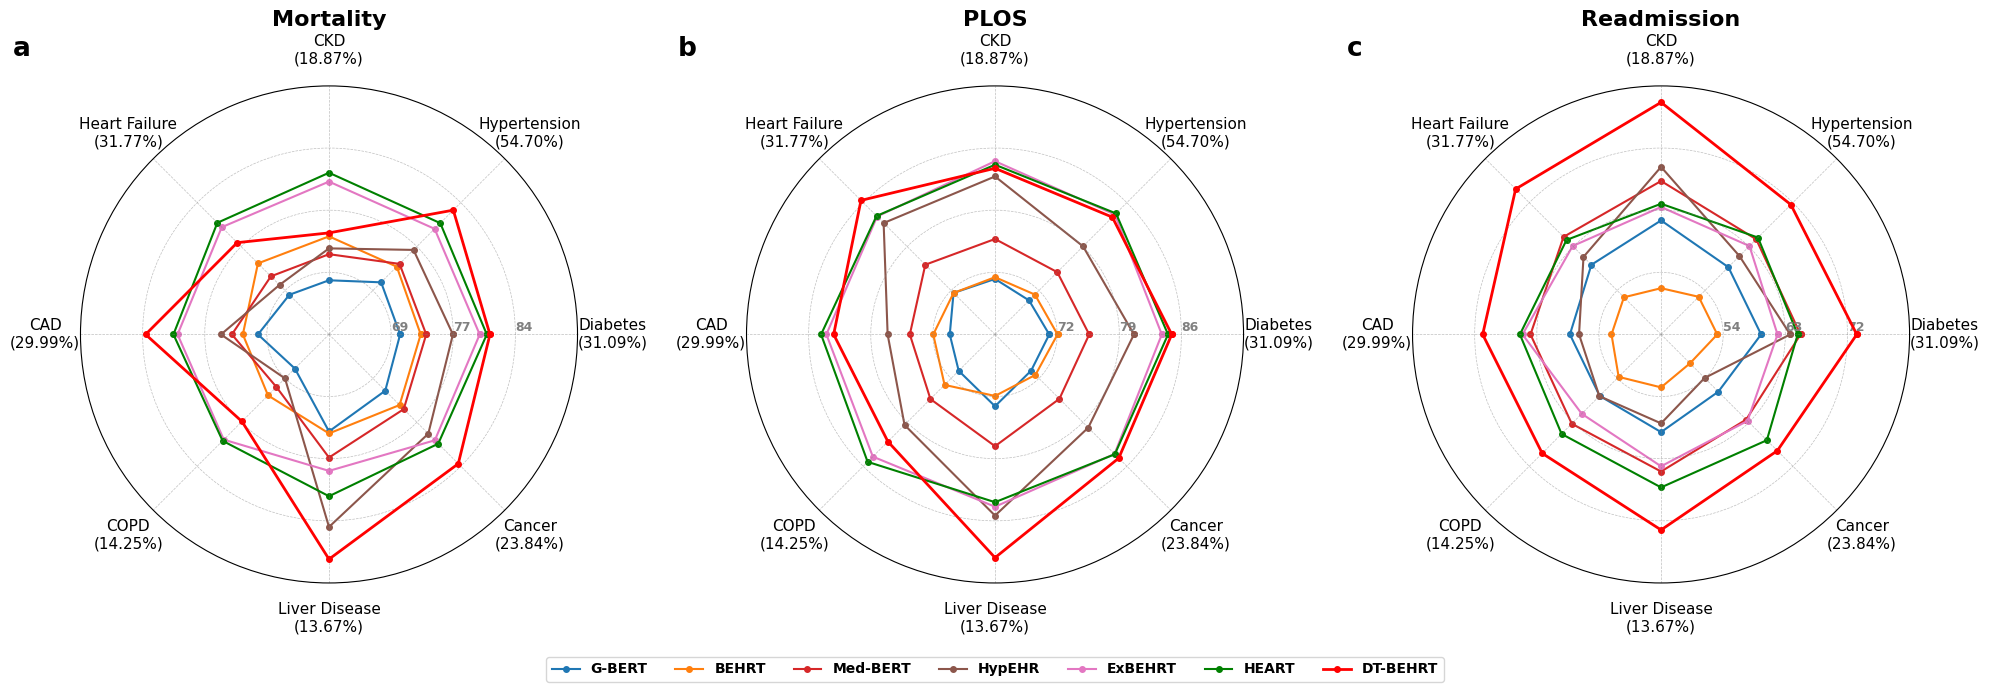

In [6]:
# ==========================================
# 2. 标签生成逻辑 (加入百分比，并创建映射)
# ==========================================
# 创建一个从 imputed_df 的 index 名称到 percent_ones 值的映射
# 依赖于 DF index 的 Subgroup 顺序和 percent_ones keys 的顺序一致
plot_subgroups_raw = imputed_df.index.get_level_values('Subgroup').unique().tolist()

# 映射：(DF中的名称 -> percent_ones值)
percent_lookup = {}
# 由于 DF index 使用的是全称，我们需要在映射时处理缩写/全称的对应
# (这里的 keys 必须与 percent_ones_series 的 index 对应，注意大小写)
percent_keys_in_order = ["DIABETES", "HYPERTENSION", "CKD", "HEART_FAILURE", 
                         "CAD", "COPD", "LIVER_DISEASE", "CANCER"]

# 假设 plot_subgroups_raw 和 percent_keys_in_order 顺序一致
for i, raw_name in enumerate(plot_subgroups_raw):
    key = percent_keys_in_order[i]
    percent_lookup[raw_name] = percent_ones.loc[key]

# 生成最终的标签列表 (包含格式化和百分比)
def generate_radar_labels(subgroup_list, percent_map):
    new_labels = []
    abbr_map = {
        "Chronic kidney disease": "CKD",
        "Coronary artery disease": "CAD",
        "Chronic obstructive pulmonary disease": "COPD",
        "Heart failure": "Heart Failure",
        "Liver disease": "Liver Disease",
        "Hypertension": "Hypertension"
    }
    
    for original_name in subgroup_list:
        display_name = abbr_map.get(original_name, original_name)
        percent = percent_map.get(original_name, 0.0)
        
        # 格式化并合并：DisplayName\n(XX.XX%)
        final_label = f"{display_name}\n({percent:.2f}%)"
        new_labels.append(final_label)
        
    return new_labels

final_labels = generate_radar_labels(plot_subgroups_raw, percent_lookup)


# ==========================================
# 3. 绘图配置 (满足所有定制需求)
# ==========================================
num_vars = len(final_labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # 闭合

fig, axes = plt.subplots(1, 3, figsize=(20, 8), subplot_kw=dict(polar=True))

# 颜色设置 (DT-BEHRT 为鲜红，其余使用 Dark2 色板)
base_palette = cm.get_cmap('tab10', len(models))
model_colors = {}
c_idx = 0
for m in models:
    if m == "DT-BEHRT":
        model_colors[m] = "red" 
    elif m == "HEART":
        model_colors[m] = "green"
    else:
        model_colors[m] = base_palette(c_idx)
        c_idx += 1

# ==========================================
# 4. 循环绘制
# ==========================================
tasks = ["Mortality", "PLOS", "Readmission"]
for ax, task in zip(axes, tasks):
    # 确保当前任务在 DF 中存在
    if task not in imputed_df.index.get_level_values('Task'): continue

    data = imputed_df.loc[task]
    
    # --- 1. 自适应 Y 轴范围计算 (防止线条挤压) ---
    min_val = data.values.min()
    max_val = data.values.max()
    lower_limit = np.floor(min_val - 5)  # 留出 5 分缓冲
    upper_limit = np.ceil(max_val + 2)
    
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # 绘制每个模型
    for model in models:
        # 使用 .loc[:, model] 确保数据切片顺序正确
        values = data.loc[:, model].values.tolist() 
        values += values[:1] # 闭合
        
        # 突出 DT-BEHRT
        lw = 2.0 if model == "DT-BEHRT" else 1.5
        zord = 10 if model == "DT-BEHRT" else 1
        
        # 绘图：无填充色，增加圆点
        ax.plot(
            angles, 
            values, 
            color=model_colors[model], 
            linewidth=lw,
            linestyle='-',
            marker='o',
            markersize=4,
            label=model,
            zorder=zord 
        )
    
    # --- 2. 坐标轴和标签设置 ---
    ax.set_xticks(angles[:-1])
    
    # 应用包含百分比的新标签，且不加粗
    ax.set_xticklabels(final_labels, size=11, weight='normal')
    
    # 将标签往外推 (增加距离)
    ax.tick_params(axis='x', pad=15) 
    
    # 应用自适应 Y 轴
    ax.set_ylim(lower_limit, upper_limit)
    
    # Y 轴刻度标签 (自适应刻度)
    ax.set_rlabel_position(0)
    y_ticks = np.linspace(lower_limit, upper_limit, 5)
    y_ticks = y_ticks[1:-1] # 移除两端的标签
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{int(y)}" for y in y_ticks], color="grey", size=9, weight='bold')
    
    ax.set_title(task, size=16, weight='bold', position=(0.5, 1.15))

# ==========================================
# 5. 图例与布局
# ==========================================
handles, model_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    model_labels,
    loc='lower center',
    ncol=len(models),
    bbox_to_anchor=(0.5, 0.05),
    fontsize=14,
    prop={'weight': 'bold'}
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.005, wspace=0.34)
add_subplot_index(axes, 1, 3, 19)

plt.show()

In [7]:
fig.savefig("./Figures/subgroup_performance_radar_all.png", dpi=300, bbox_inches='tight')